In [1]:
# Import the libraries
import pandas as pd 
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
# To Read the Data
df =pd.read_csv("Walmart.csv")
print(df)


      Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0         1  05-02-2010    1643690.90             0        42.31       2.572   
1         1  12-02-2010    1641957.44             1        38.51       2.548   
2         1  19-02-2010    1611968.17             0        39.93       2.514   
3         1  26-02-2010    1409727.59             0        46.63       2.561   
4         1  05-03-2010    1554806.68             0        46.50       2.625   
...     ...         ...           ...           ...          ...         ...   
6430     45  28-09-2012     713173.95             0        64.88       3.997   
6431     45  05-10-2012     733455.07             0        64.89       3.985   
6432     45  12-10-2012     734464.36             0        54.47       4.000   
6433     45  19-10-2012     718125.53             0        56.47       3.969   
6434     45  26-10-2012     760281.43             0        58.85       3.882   

             CPI  Unemployment  
0     

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [4]:
# Here to change all of Holiday_Flag and Store datatype to category datatype.
df['Holiday_Flag']=df['Holiday_Flag'].astype('category')
df['Store']=df['Store'].astype('category')

In [5]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   category      
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   category      
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: category(2), datetime64[ns](1), float64(5)
memory usage: 315.9 KB


In [ ]:
# To find the Missing Values. 
df.isna().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [ ]:
# To find if the data has a duplicate values or not.
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Date,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment
count,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000
mean,2011-06-17 00:00:00,1.046965e+06,60.663782,3.358607,171.578394,7.999151
min,2010-02-05 00:00:00,2.099862e+05,-2.060000,2.472000,126.064000,3.879000
25%,2010-10-08 00:00:00,5.533501e+05,47.460000,2.933000,131.735000,6.891000
50%,2011-06-17 00:00:00,9.607460e+05,62.670000,3.445000,182.616521,7.874000
75%,2012-02-24 00:00:00,1.420159e+06,74.940000,3.735000,212.743293,8.622000
max,2012-10-26 00:00:00,3.818686e+06,100.140000,4.468000,227.232807,14.313000
std,NaN,5.643666e+05,18.444933,0.459020,39.356712,1.875885


In [ ]:
# Choose only the colums has a Numerical datatype.
numcol = df.select_dtypes('number').columns
len(numcol)

5

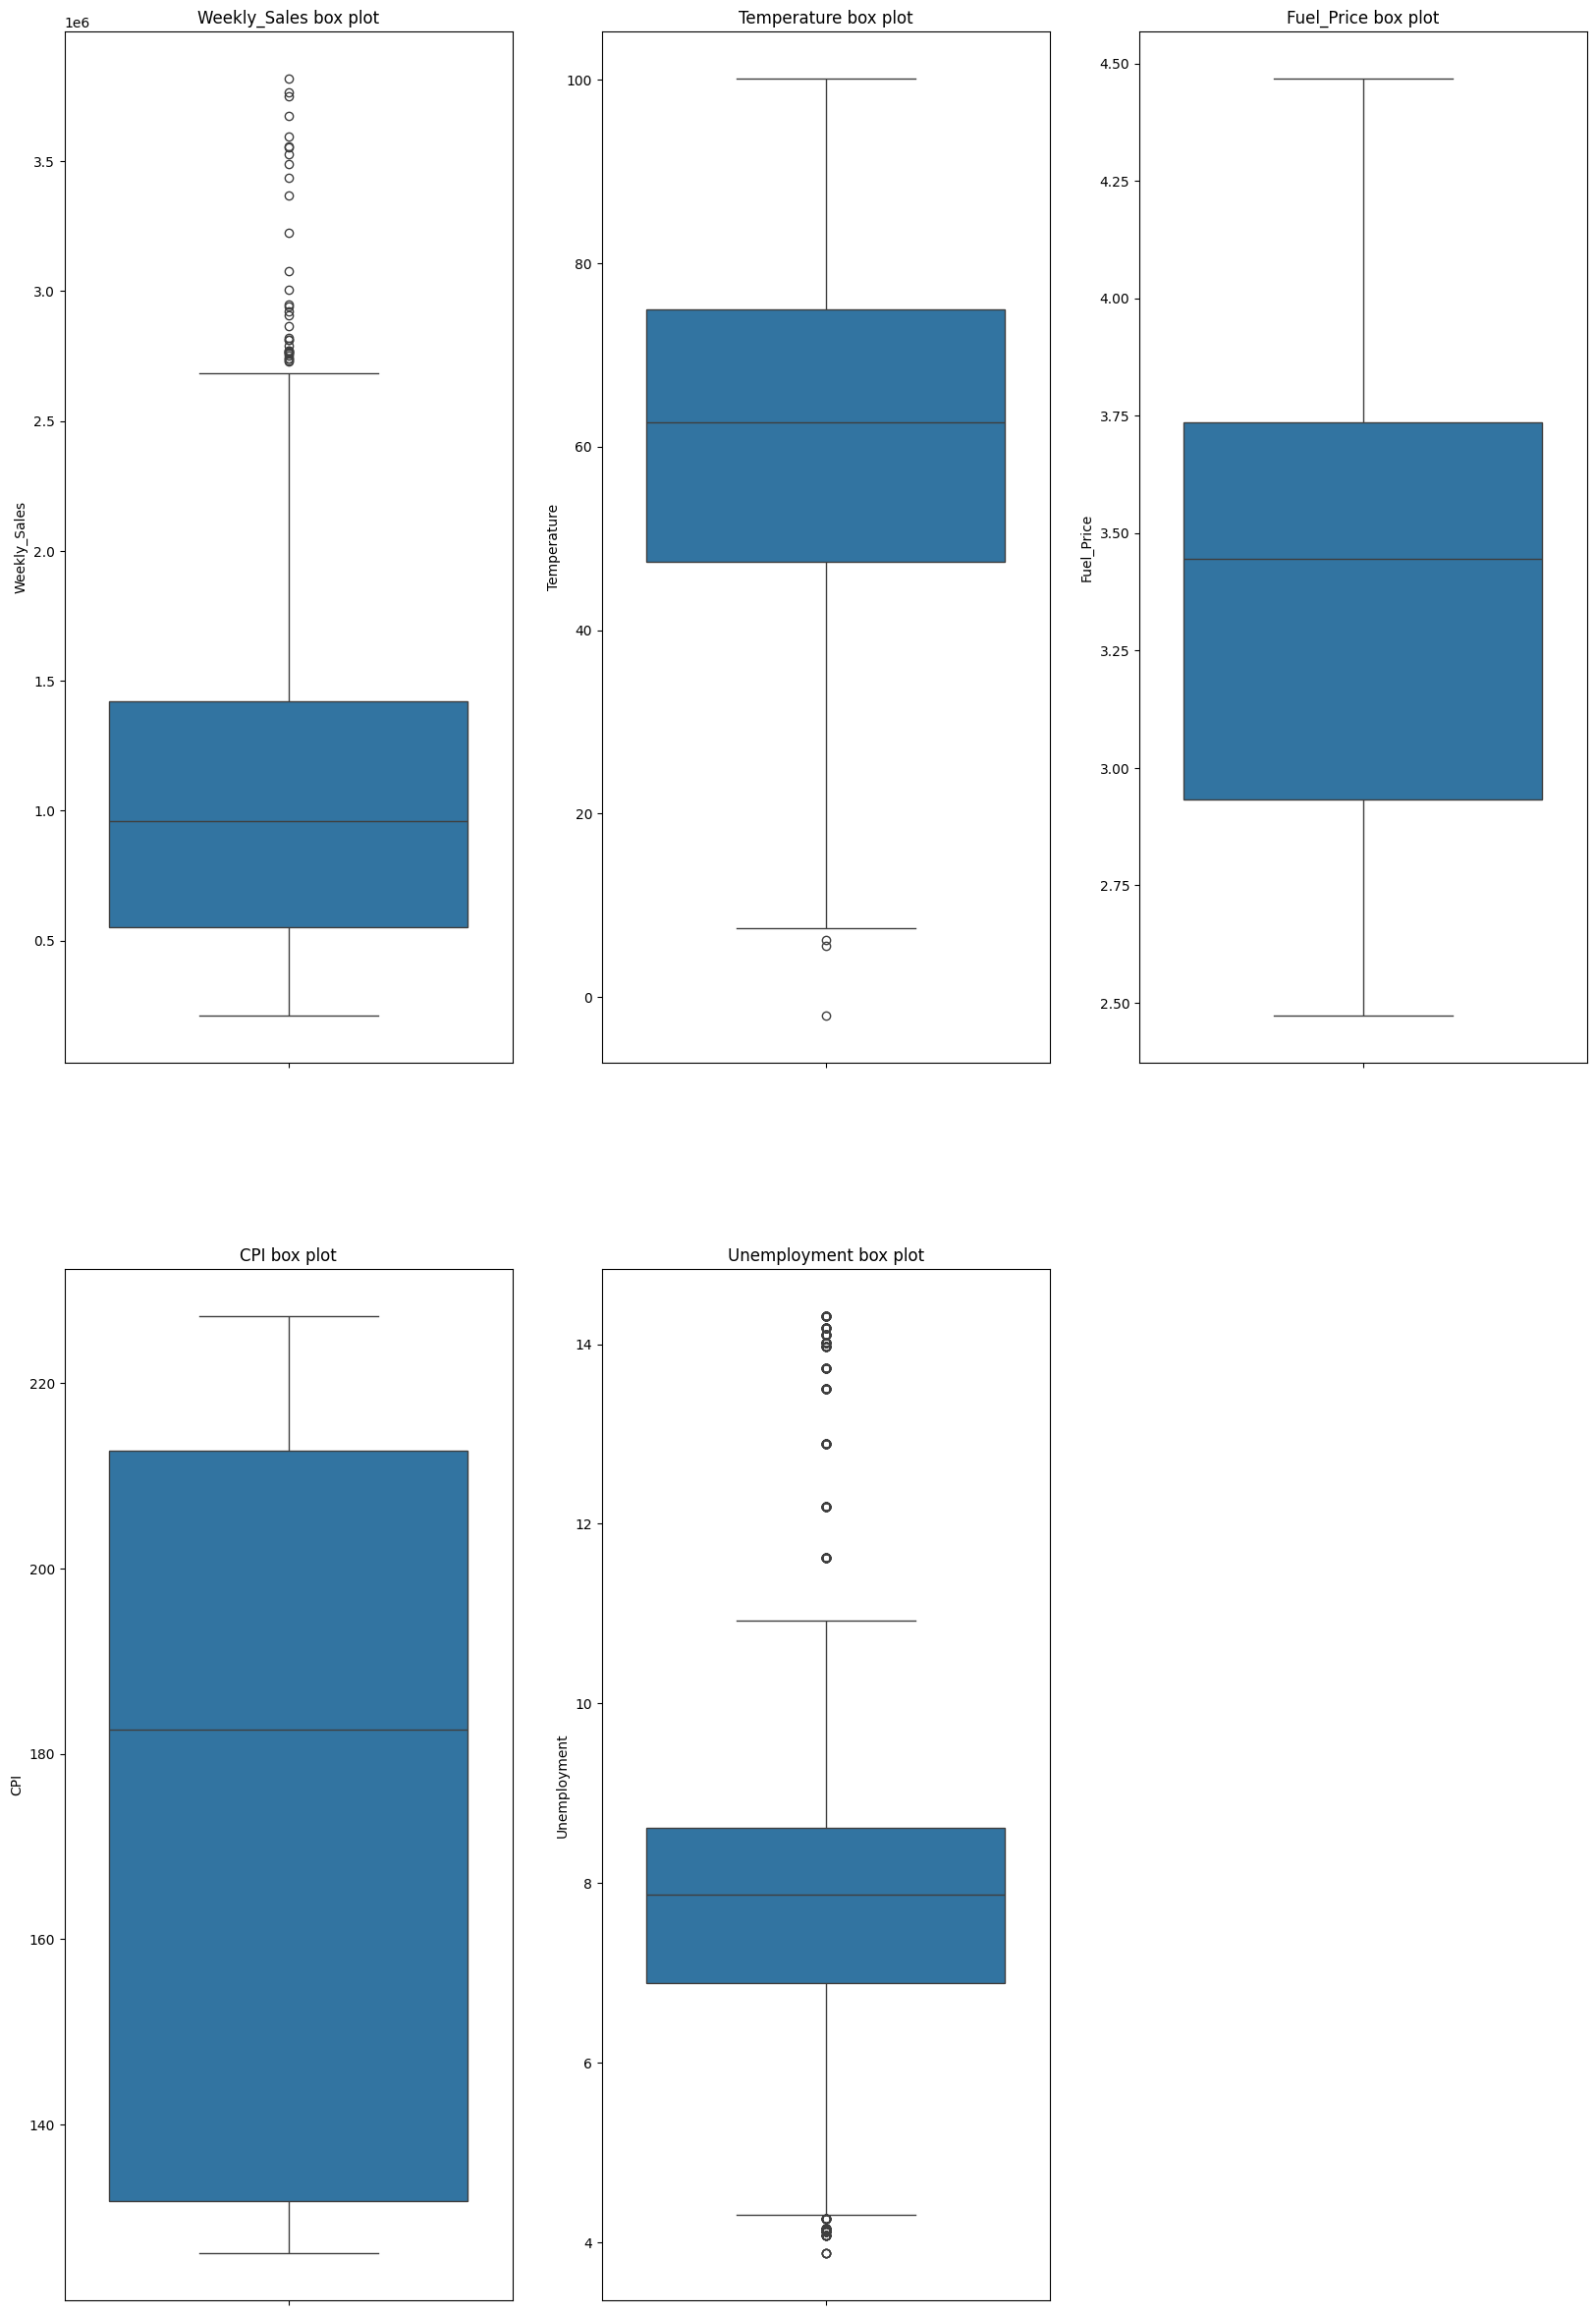

In [ ]:
 # Drow a box plot digram to see the Outliers.
plt.figure(figsize=(20,30))

for i , col in enumerate(numcol):
    plt.subplot(2,3,i+1)
    sns.boxplot(df[col])
    plt.title(f"{col} box plot")
plt.show()

In [ ]:
# Standardize Weekly_Sales to put it on a common scale
SD = StandardScaler()
df['Weekly_Sales'] = SD.fit_transform(df[['Weekly_Sales']])


In [13]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1.057420,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1.054348,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1.001206,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,0.642828,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,0.899914,0,46.50,2.625,211.350143,8.106


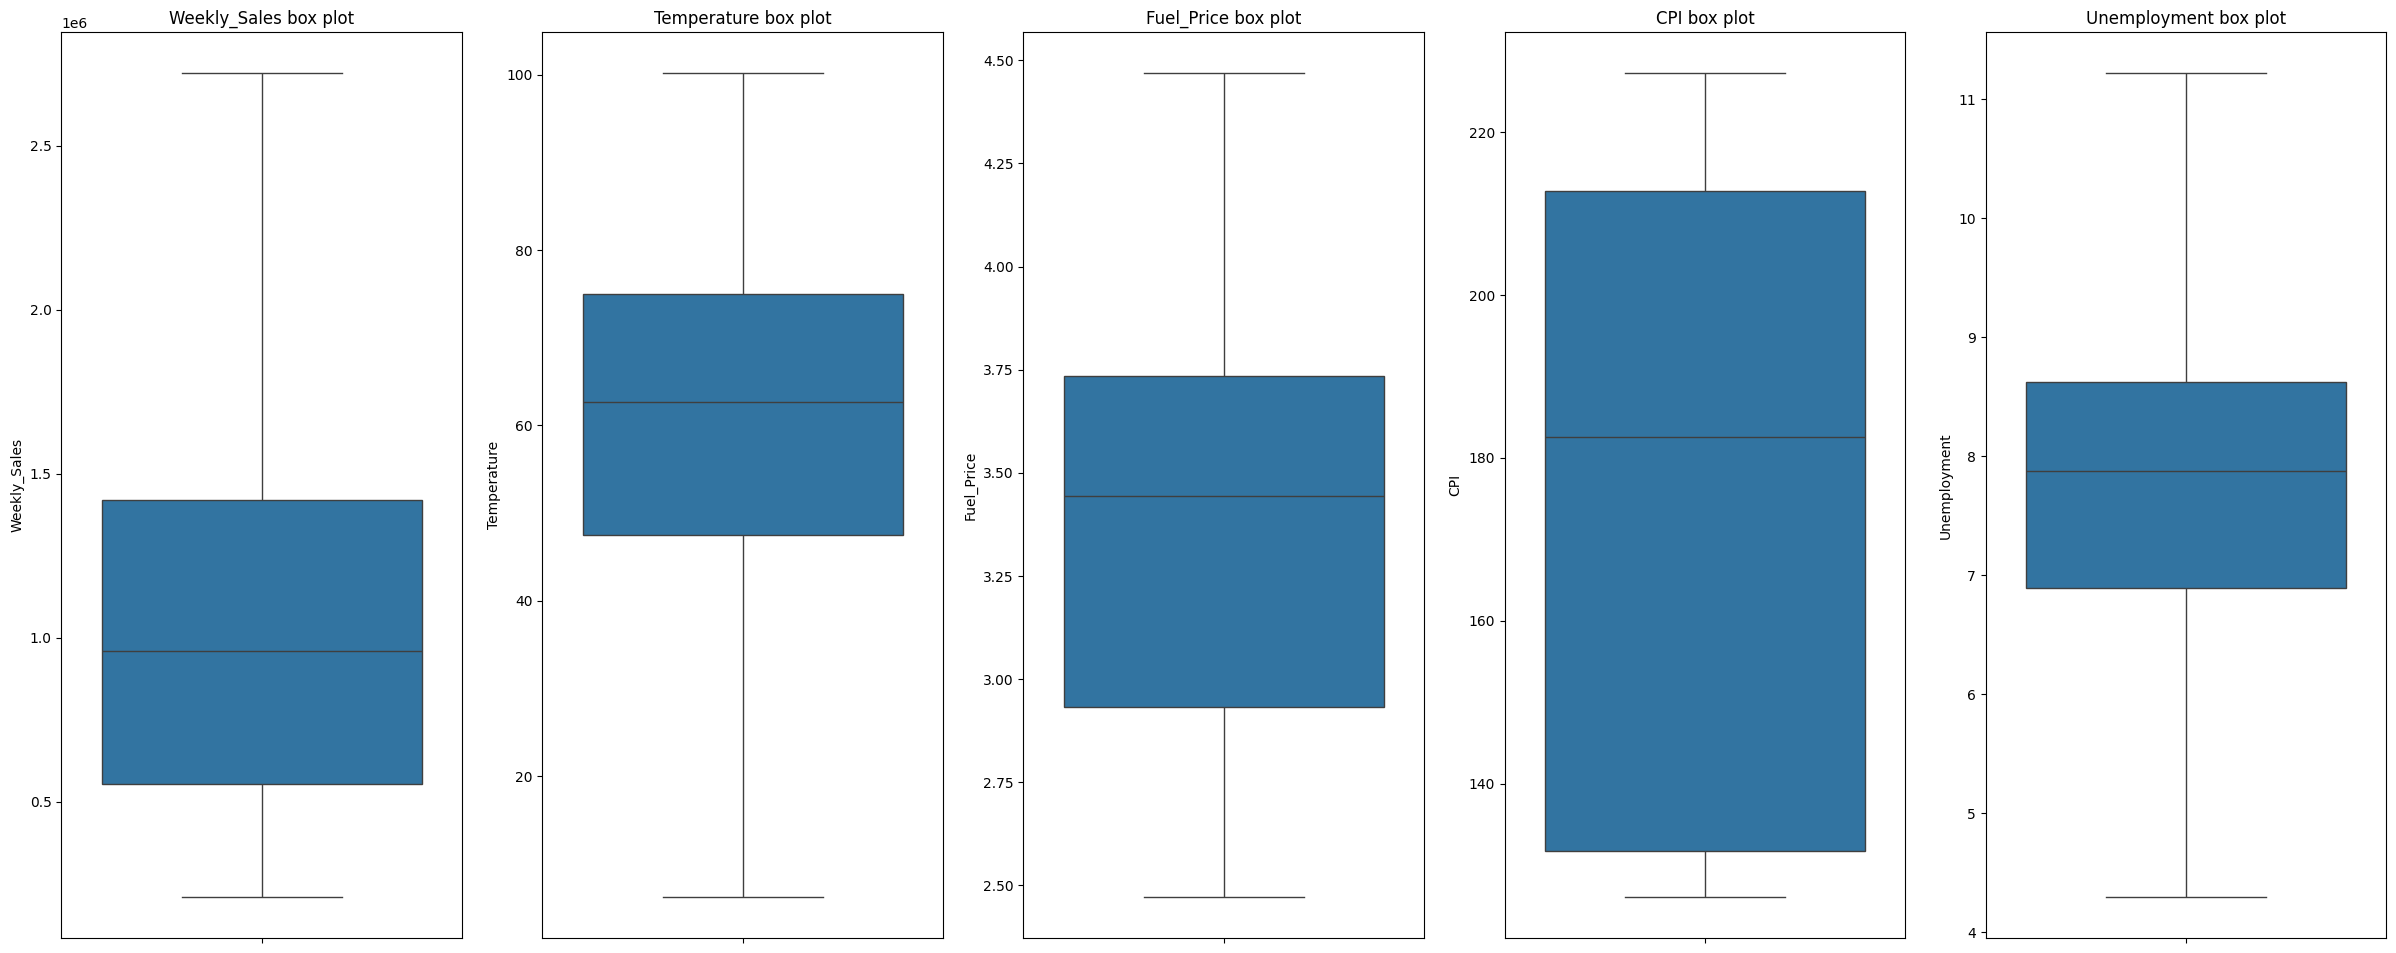

In [37]:
# Detect and handle outliers in numerical columns using the IQR method.
for col in numcol:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    UP_FENNCE = Q3 + 1.5 * IQR
    LO_FENNCE = Q1 - 1.5 * IQR
    lowOutlier = df[df[col] < LO_FENNCE][col].values
    upOutlier = df[df[col] > UP_FENNCE][col].values
    df[col].replace(lowOutlier, LO_FENNCE, inplace=True)
    df[col].replace(upOutlier, UP_FENNCE, inplace=True)

plt.figure(figsize=(30,40))

# Box plots are then used to visualize the data distribution after treatment.
for i, col in enumerate(numcol):
    plt.subplot(3, 5, i+1)
    sns.boxplot(df[col])
    plt.title(f"{col} box plot")
plt.show()


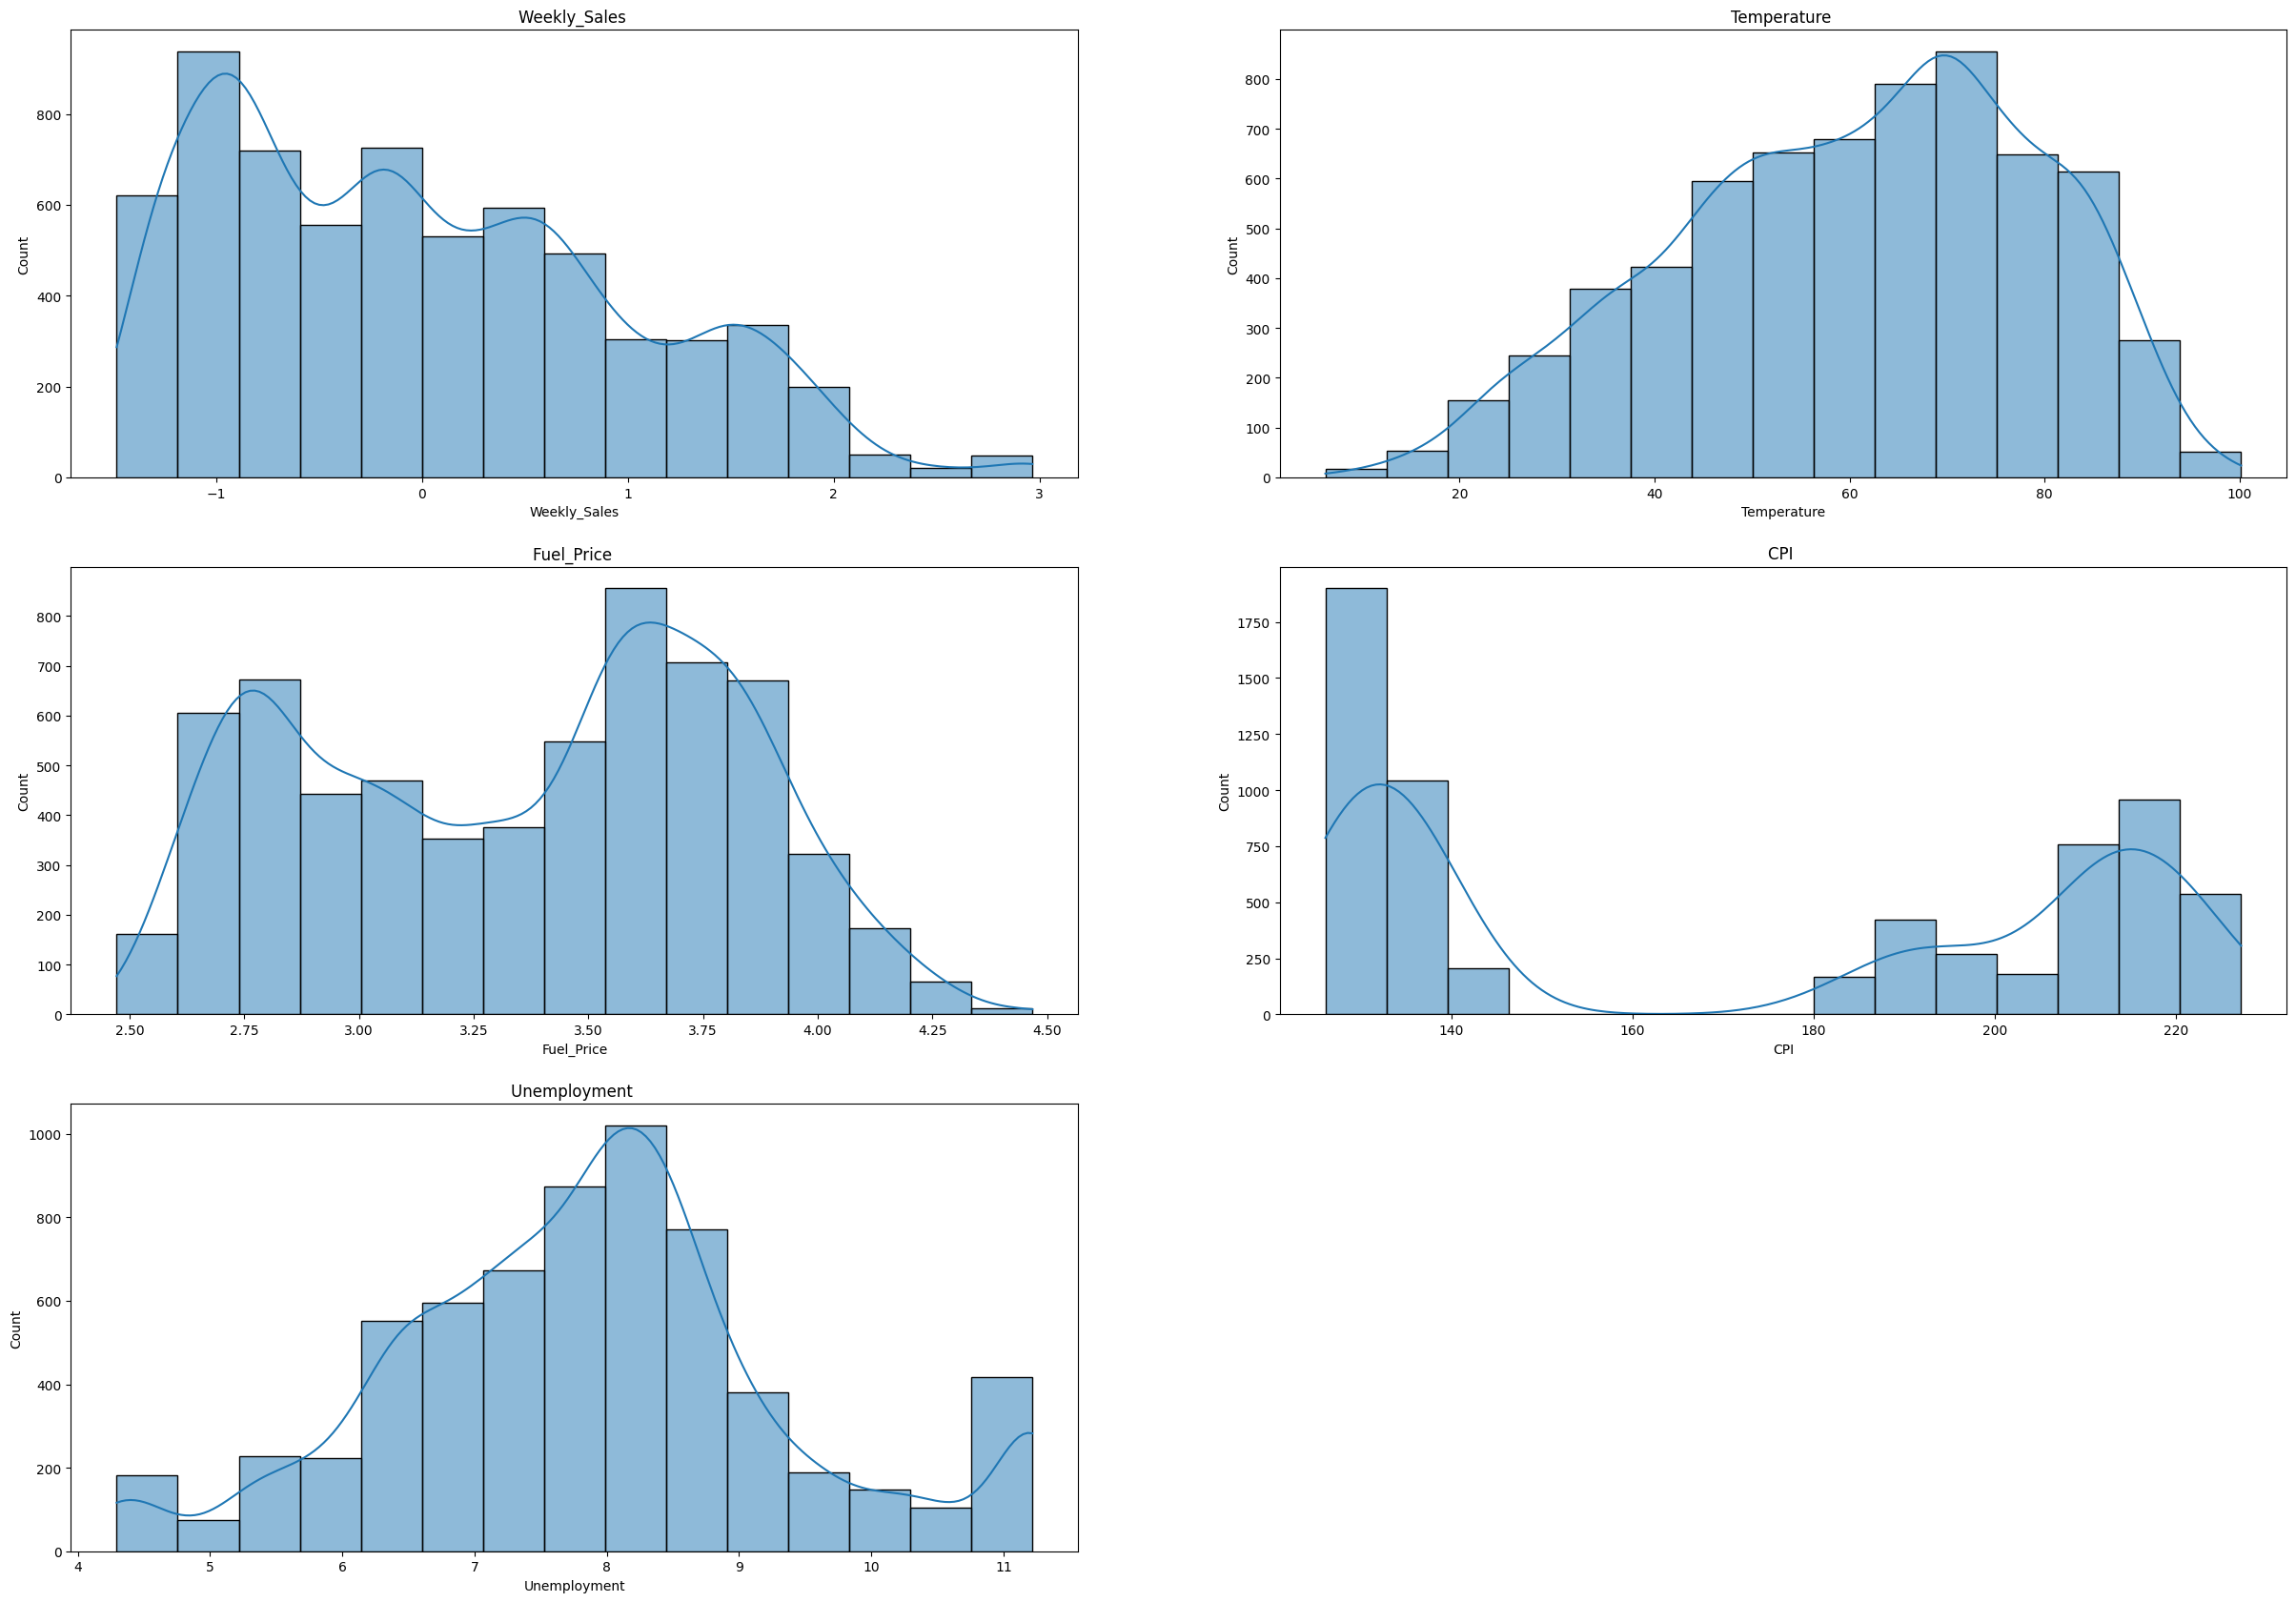

In [ ]:
# Plot histograms with KDE for all numerical columns
plt.figure(figsize=(30,50))
for i, col in enumerate(numcol):
    plt.subplot(7, 2, i+1)
    sns.histplot(df[col] , kde=True , bins=15)
    plt.title(f"{col} ")
plt.show()

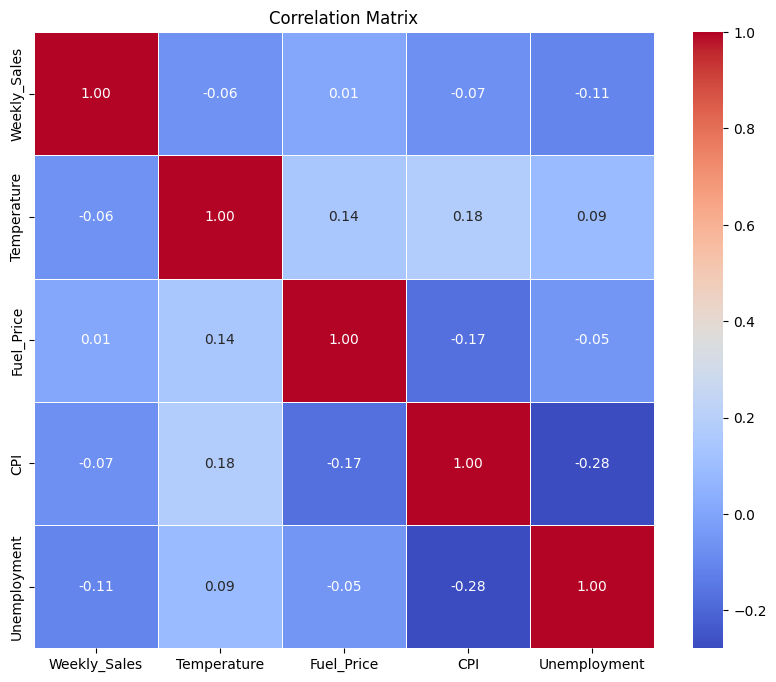

In [16]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# Calculate total weekly sales per store and extract the top 10 stores by total sales
top_10_stores_total = (
    df.groupby('Store')['Weekly_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)


C:\Users\El-Wattaneya\AppData\Local\Temp\ipykernel_27256\2057183258.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Store')['Weekly_Sales']


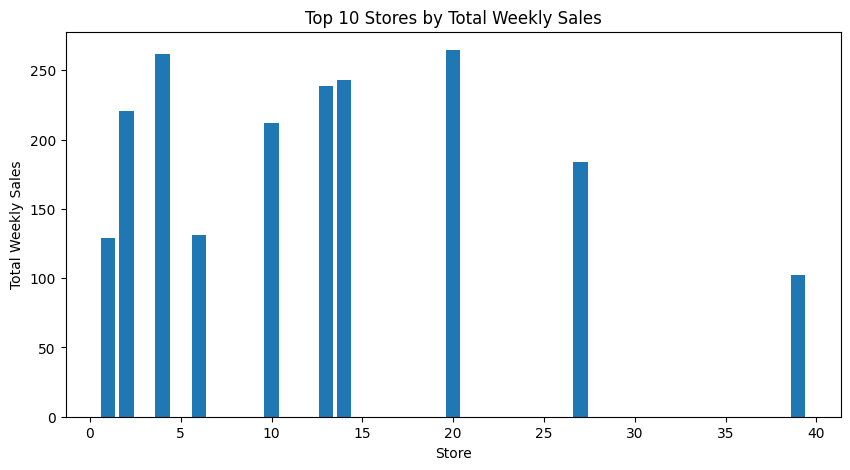

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(top_10_stores_total['Store'], top_10_stores_total['Weekly_Sales'])
plt.xlabel('Store')
plt.ylabel('Total Weekly Sales')
plt.title('Top 10 Stores by Total Weekly Sales')
plt.show()

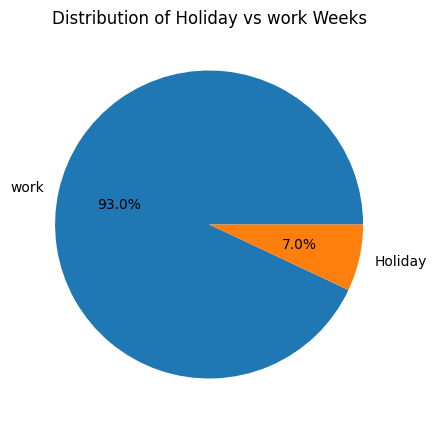

In [20]:
plt.figure(figsize=(10,5))
plt.pie(df['Holiday_Flag'].value_counts(),labels=['work','Holiday'],autopct='%1.1f%%')
plt.title('Distribution of Holiday vs work Weeks')
plt.show()

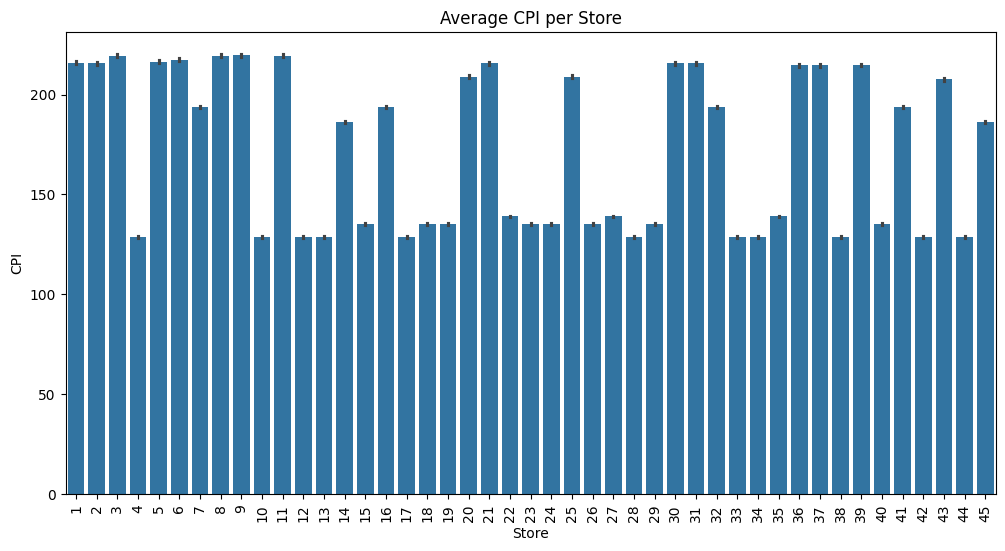

In [21]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Store', y='CPI', estimator='mean')
plt.title('Average CPI per Store')
plt.xticks(rotation=90)
plt.show()


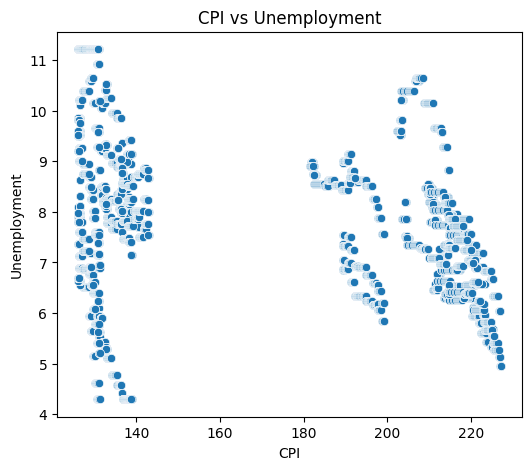

In [22]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x='CPI',
    y='Unemployment',
)
plt.title('CPI vs Unemployment')
plt.show()

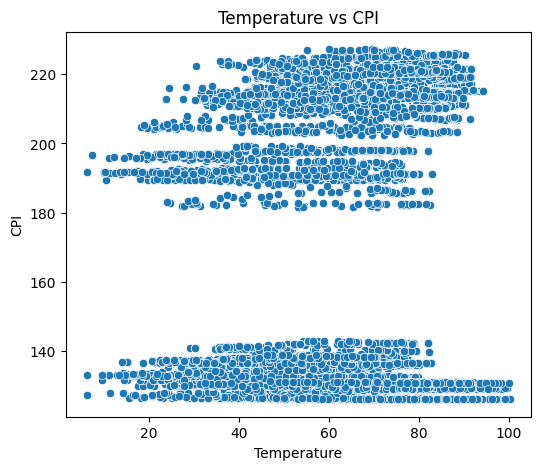

In [23]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x='Temperature',
    y='CPI',

)
plt.title('Temperature vs CPI')
plt.show()


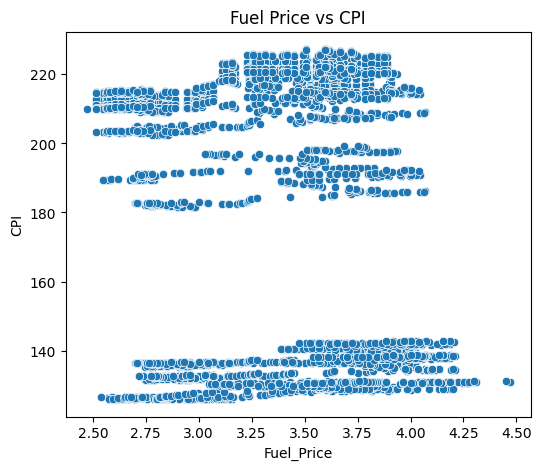

In [24]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x='Fuel_Price',
    y='CPI',

)
plt.title('Fuel Price vs CPI')
plt.show()


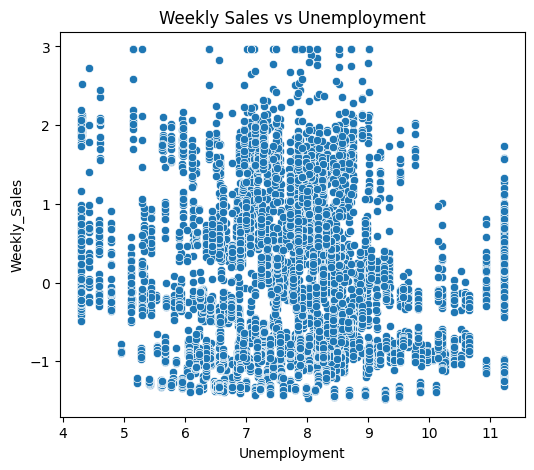

In [25]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x='Unemployment',
    y='Weekly_Sales',

)
plt.title('Weekly Sales vs Unemployment')
plt.show()


In [26]:
df_ts = (
    df.groupby('Date')[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]
      .mean()
      .reset_index()
      .sort_values('Date')
)


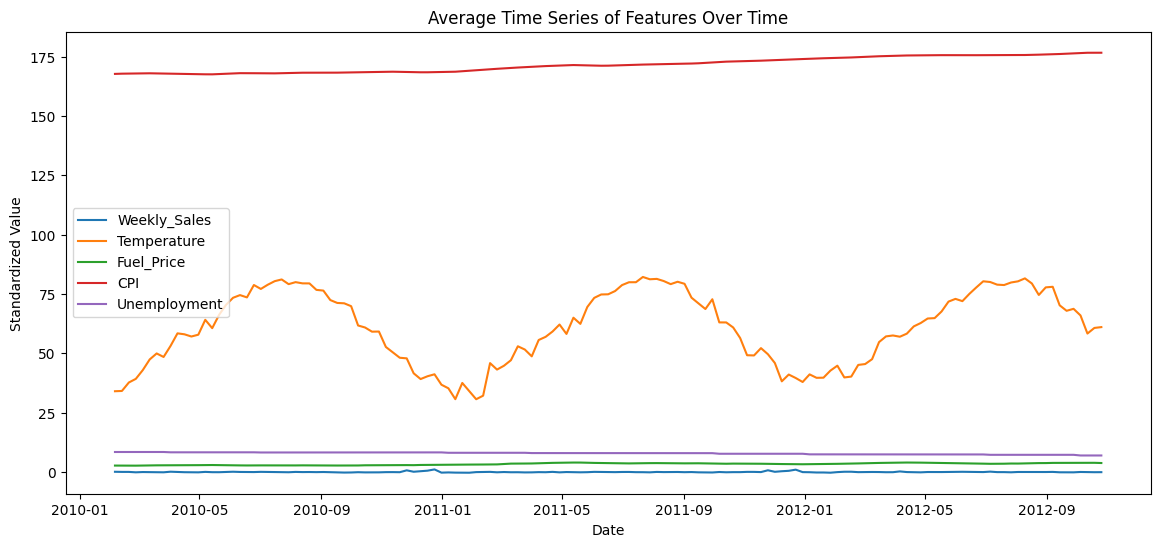

In [27]:
plt.figure(figsize=(14,6))

for col in numcol:
    plt.plot(df_ts['Date'], df_ts[col], label=col)

plt.xlabel('Date')
plt.ylabel('Standardized Value')
plt.title('Average Time Series of Features Over Time')
plt.legend()
plt.show()

In [28]:
df = pd.read_csv("Walmart.csv")
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)
df['Year'] = df['Date'].dt.year


In [29]:
yearly_sales = (
    df.groupby('Year')['Weekly_Sales']
      .sum()
      .reset_index()
)
yearly_sales


,Year,Weekly_Sales
0,2010,2.288886e+09
1,2011,2.448200e+09
2,2012,2.000133e+09


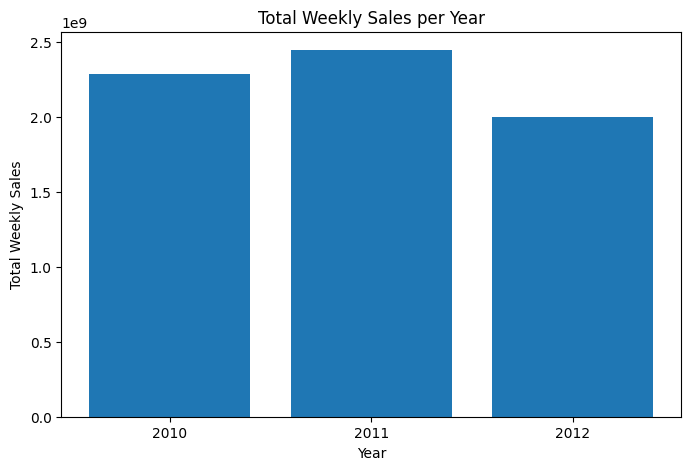

In [30]:
plt.figure(figsize=(8,5))
plt.bar(yearly_sales['Year'], yearly_sales['Weekly_Sales'])
plt.xlabel('Year')
plt.ylabel('Total Weekly Sales')
plt.title('Total Weekly Sales per Year')
plt.xticks(yearly_sales['Year'])
plt.show()

In [31]:
yearly_CPI = (
    df.groupby('Year')['CPI']
      .sum()
      .reset_index()
)
yearly_CPI


,Year,CPI
0,2010,363099.848068
1,2011,401416.975385
2,2012,339590.140964


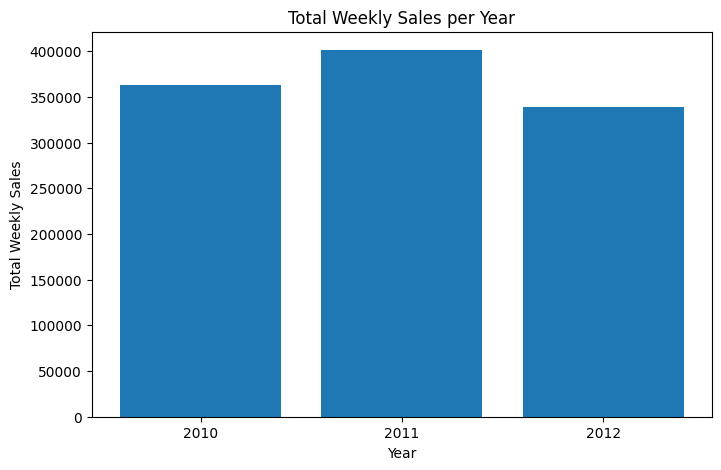

In [32]:
plt.figure(figsize=(8,5))
plt.bar(yearly_CPI['Year'], yearly_CPI['CPI'])
plt.xlabel('Year')
plt.ylabel('Total Weekly Sales')
plt.title('Total Weekly Sales per Year')
plt.xticks(yearly_CPI['Year'])
plt.show()